In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from PIL import Image
import matplotlib.pyplot as plt

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"CUDA available: {torch.cuda.is_available()}")

Using device: cuda
CUDA available: True


In [3]:
class DeepfakeDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.classes = ['Real', 'Fake']
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}
        self.images = self._load_images()

    def _load_images(self):
        images = []
        for cls in self.classes:
            class_dir = os.path.join(self.root_dir, cls)
            for img_name in os.listdir(class_dir):
                images.append((os.path.join(class_dir, img_name), self.class_to_idx[cls]))
        return images

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path, label = self.images[idx]
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
        
        return image, label

In [4]:
class DeepfakeDetector(nn.Module):
    def __init__(self):
        super(DeepfakeDetector, self).__init__()
        self.resnet = models.resnet50(pretrained=True)
        self.resnet = nn.Sequential(*list(self.resnet.children())[:-2])
        
        self.fpn_layers = nn.ModuleList([
            nn.Conv2d(2048, 256, kernel_size=1),
            nn.Conv2d(1024, 256, kernel_size=1),
            nn.Conv2d(512, 256, kernel_size=1),
            nn.Conv2d(256, 256, kernel_size=1)
        ])
        
        self.top_down_layers = nn.ModuleList([
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.Conv2d(256, 256, kernel_size=3, padding=1)
        ])
        
        self.final_layer = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(256, 2)
        )

    def forward(self, x):
        c2 = self.resnet[:5](x)
        c3 = self.resnet[5](c2)
        c4 = self.resnet[6](c3)
        c5 = self.resnet[7](c4)
        
        p5 = self.fpn_layers[0](c5)
        p4 = self.fpn_layers[1](c4) + nn.functional.interpolate(p5, scale_factor=2, mode='nearest')
        p3 = self.fpn_layers[2](c3) + nn.functional.interpolate(p4, scale_factor=2, mode='nearest')
        p2 = self.fpn_layers[3](c2) + nn.functional.interpolate(p3, scale_factor=2, mode='nearest')
        
        d5 = self.top_down_layers[0](p5)
        d4 = self.top_down_layers[1](p4)
        d3 = self.top_down_layers[2](p3)
        d2 = self.top_down_layers[3](p2)
        
        d5 = nn.functional.interpolate(d5, size=d2.shape[2:], mode='nearest')
        d4 = nn.functional.interpolate(d4, size=d2.shape[2:], mode='nearest')
        d3 = nn.functional.interpolate(d3, size=d2.shape[2:], mode='nearest')
        
        combined = d5 + d4 + d3 + d2
        out = self.final_layer(combined)
        return out

In [5]:
def preprocess_data():
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    train_dataset = DeepfakeDataset(root_dir='/kaggle/input/deepfake-and-real-images/Dataset/Train', transform=transform)
    val_dataset = DeepfakeDataset(root_dir='/kaggle/input/deepfake-and-real-images/Dataset/Validation', transform=transform)
    test_dataset = DeepfakeDataset(root_dir='/kaggle/input/deepfake-and-real-images/Dataset/Test', transform=transform)

    print(f"Train dataset size: {len(train_dataset)}")
    print(f"Validation dataset size: {len(val_dataset)}")
    print(f"Test dataset size: {len(test_dataset)}")

    return train_dataset, val_dataset, test_dataset

In [6]:
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs):
    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        for i, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            
            if i % 10 == 0:
                print(f'Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{len(train_loader)}], Loss: {loss.item():.4f}')
        
        # Validation
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        
        print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss/len(train_loader):.4f}, '
              f'Val Loss: {val_loss/len(val_loader):.4f}, Val Accuracy: {100 * correct / total:.2f}%')


In [7]:
def evaluate_model(model, test_loader):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='weighted')
    recall = recall_score(all_labels, all_preds, average='weighted')
    f1 = f1_score(all_labels, all_preds, average='weighted')
    
    print(f'Test Accuracy: {accuracy:.4f}')
    print(f'Test Precision: {precision:.4f}')
    print(f'Test Recall: {recall:.4f}')
    print(f'Test F1-score: {f1:.4f}')

In [8]:
train_dataset, val_dataset, test_dataset = preprocess_data()

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

model = DeepfakeDetector().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

Train dataset size: 140002
Validation dataset size: 39428
Test dataset size: 10905


/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [9]:
train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=10)

Epoch [1/10], Step [1/4376], Loss: 0.6691
Epoch [1/10], Step [11/4376], Loss: 1.1785
Epoch [1/10], Step [21/4376], Loss: 1.5060
Epoch [1/10], Step [31/4376], Loss: 1.3642
Epoch [1/10], Step [41/4376], Loss: 0.9000
Epoch [1/10], Step [51/4376], Loss: 0.7633
Epoch [1/10], Step [61/4376], Loss: 0.7369
Epoch [1/10], Step [71/4376], Loss: 0.7440
Epoch [1/10], Step [81/4376], Loss: 0.7296
Epoch [1/10], Step [91/4376], Loss: 0.6465
Epoch [1/10], Step [101/4376], Loss: 0.7050
Epoch [1/10], Step [111/4376], Loss: 0.7132
Epoch [1/10], Step [121/4376], Loss: 0.6798
Epoch [1/10], Step [131/4376], Loss: 0.6760
Epoch [1/10], Step [141/4376], Loss: 0.7378
Epoch [1/10], Step [151/4376], Loss: 0.6666
Epoch [1/10], Step [161/4376], Loss: 0.6735
Epoch [1/10], Step [171/4376], Loss: 0.6995
Epoch [1/10], Step [181/4376], Loss: 0.6729
Epoch [1/10], Step [191/4376], Loss: 0.7484
Epoch [1/10], Step [201/4376], Loss: 0.6879
Epoch [1/10], Step [211/4376], Loss: 0.6303
Epoch [1/10], Step [221/4376], Loss: 0.7838

In [10]:
evaluate_model(model, test_loader)

Test Accuracy: 0.9137
Test Precision: 0.9141
Test Recall: 0.9137
Test F1-score: 0.9137


In [11]:
torch.save(model.state_dict(), 'deepfake_detector.pth')

In [15]:
def predict_image(model, image_path):
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    image = Image.open(image_path).convert('RGB')
    image = transform(image).unsqueeze(0).to(device)
    
    model.eval()
    with torch.no_grad():
        output = model(image)
        _, predicted = torch.max(output.data, 1)
    
    return "Fake" if predicted.item() == 1 else "Real"

Cell 14 executed successfully: Additional libraries imported


/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
<ipython-input-16-0ebeaf3315b5>:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more detai

Cell 15 executed successfully: Previously trained model loaded
Cell 16 executed successfully: Prediction function defined
Cell 17 executed successfully: Predictions obtained for test set


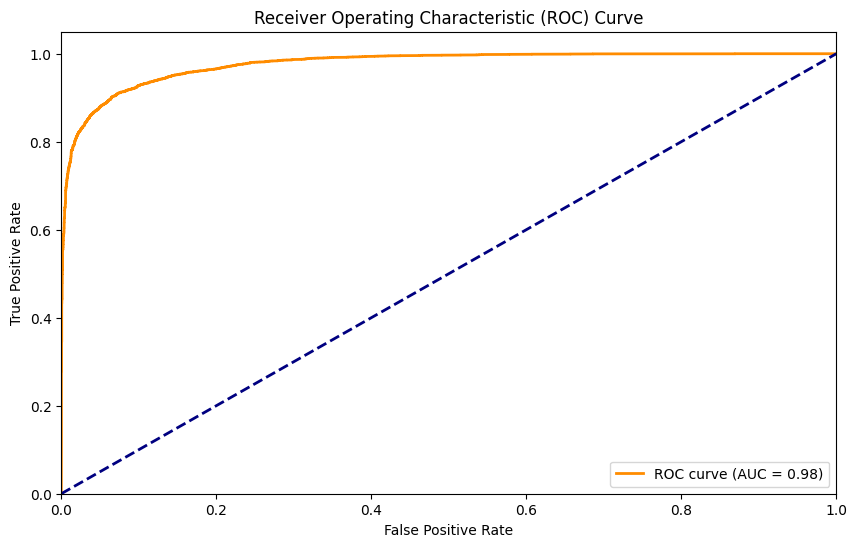

ROC AUC: 0.9761
Cell 18 executed successfully: ROC Curve plotted


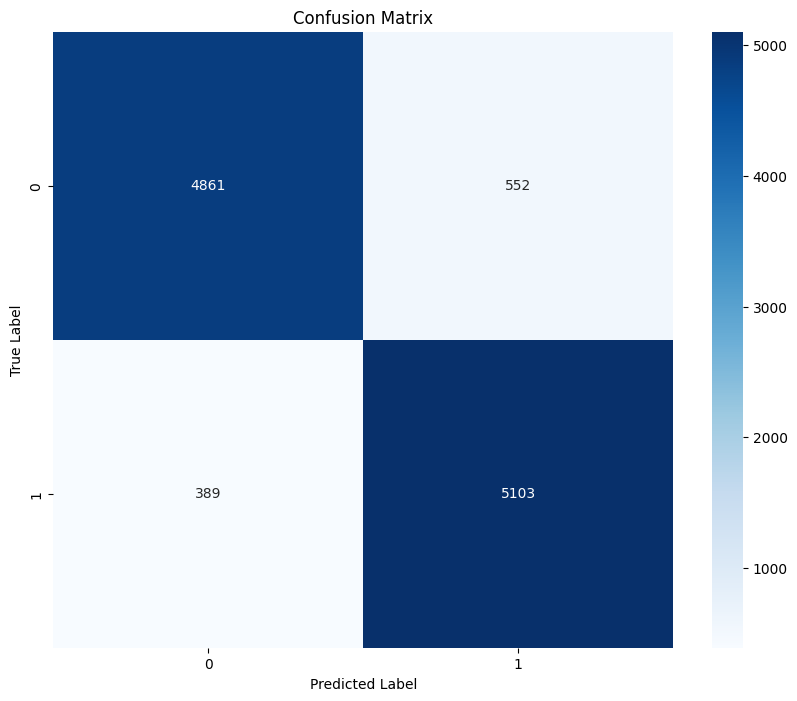

Cell 19 executed successfully: Confusion Matrix plotted
Accuracy: 0.9137
Precision: 0.9024
Recall (Sensitivity): 0.9292
F1-score: 0.9156
Specificity: 0.8980
ROC AUC: 0.9761
Cell 20 executed successfully: Additional metrics calculated


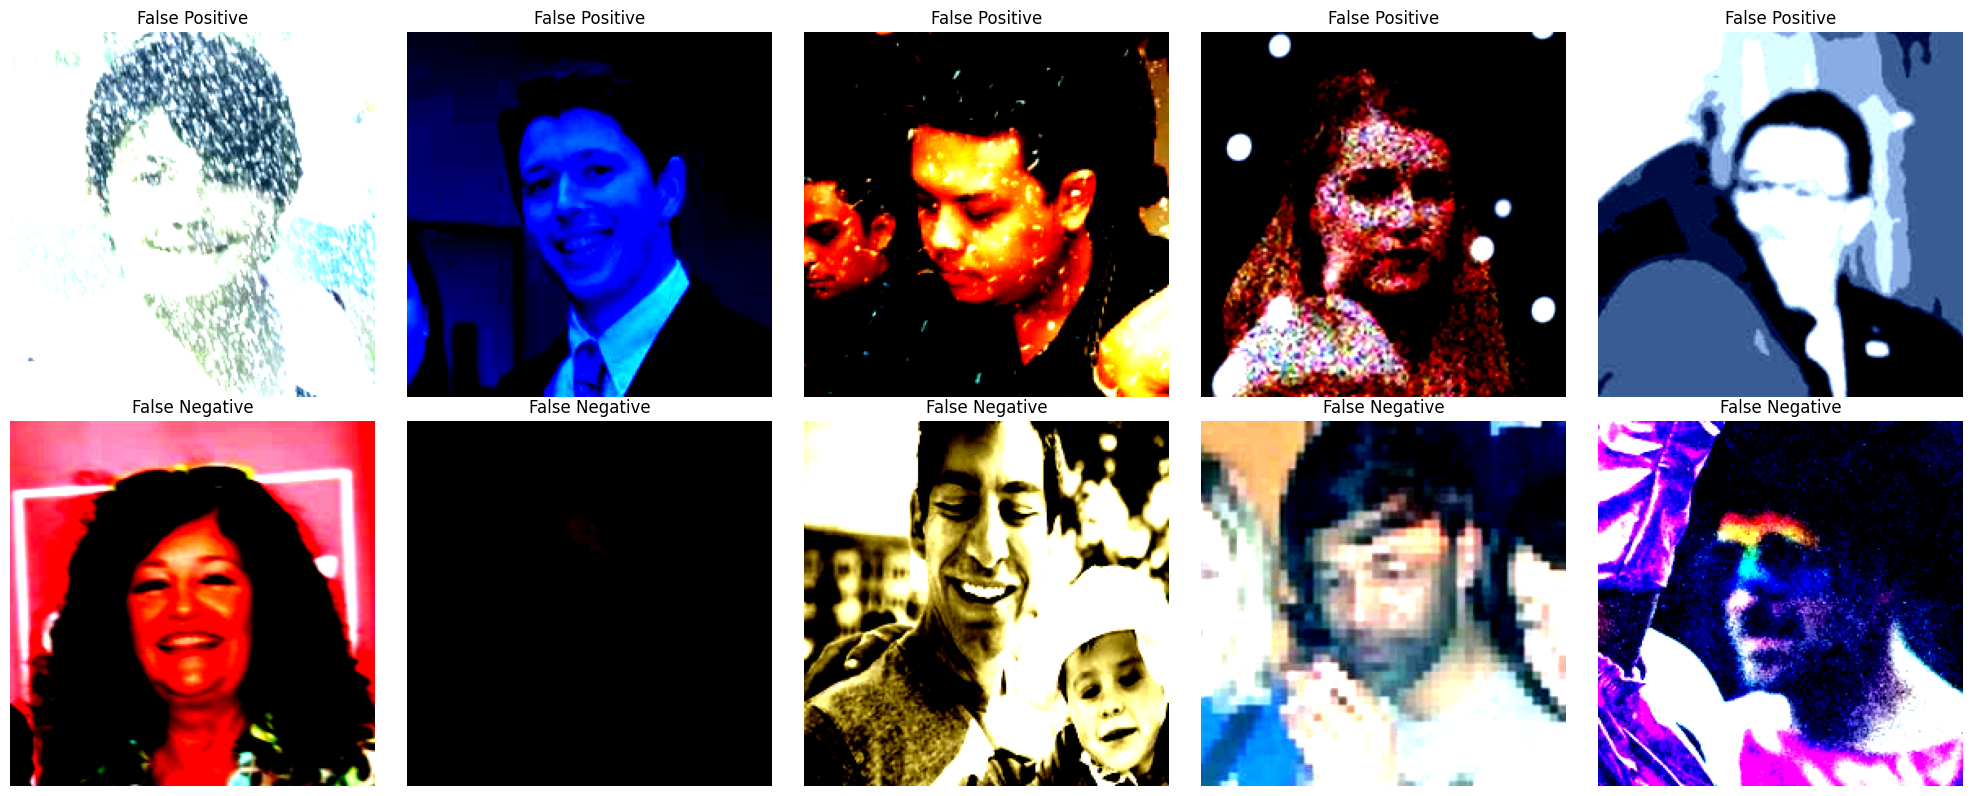

Cell 21 executed successfully: Error examples plotted


In [16]:
# Cell 14: Import additional libraries
import numpy as np
from sklearn.metrics import roc_curve, auc, confusion_matrix
import seaborn as sns

print("Cell 14 executed successfully: Additional libraries imported")

# Cell 15: Load the previously trained model
model = DeepfakeDetector().to(device)
model.load_state_dict(torch.load('deepfake_detector.pth'))
model.eval()

print("Cell 15 executed successfully: Previously trained model loaded")

# Cell 16: Function to get predictions and true labels
def get_predictions(model, data_loader):
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs, 1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())  # Probability of being fake
    
    return np.array(all_preds), np.array(all_labels), np.array(all_probs)

print("Cell 16 executed successfully: Prediction function defined")

# Cell 17: Get predictions for test set
test_preds, test_labels, test_probs = get_predictions(model, test_loader)

print("Cell 17 executed successfully: Predictions obtained for test set")

# Cell 18: ROC Curve
def plot_roc_curve(y_true, y_scores):
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(10, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.show()
    
    return roc_auc

roc_auc = plot_roc_curve(test_labels, test_probs)
print(f"ROC AUC: {roc_auc:.4f}")
print("Cell 18 executed successfully: ROC Curve plotted")

# Cell 19: Confusion Matrix
def plot_confusion_matrix(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()
    
    return cm

cm = plot_confusion_matrix(test_labels, test_preds)
print("Cell 19 executed successfully: Confusion Matrix plotted")

# Cell 20: Additional Metrics
def calculate_metrics(confusion_matrix, roc_auc):
    tn, fp, fn, tp = confusion_matrix.ravel()
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp)
    recall = tp / (tp + fn)
    f1_score = 2 * (precision * recall) / (precision + recall)
    specificity = tn / (tn + fp)
    
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall (Sensitivity): {recall:.4f}")
    print(f"F1-score: {f1_score:.4f}")
    print(f"Specificity: {specificity:.4f}")
    print(f"ROC AUC: {roc_auc:.4f}")

calculate_metrics(cm, roc_auc)
print("Cell 20 executed successfully: Additional metrics calculated")

# Cell 21: Error Analysis
def plot_error_examples(model, test_loader, num_examples=5):
    model.eval()
    errors = {'false_positives': [], 'false_negatives': []}
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            
            false_positives = (predicted == 1) & (labels == 0)
            false_negatives = (predicted == 0) & (labels == 1)
            
            errors['false_positives'].extend(images[false_positives].cpu())
            errors['false_negatives'].extend(images[false_negatives].cpu())
            
            if len(errors['false_positives']) >= num_examples and len(errors['false_negatives']) >= num_examples:
                break
    
    fig, axes = plt.subplots(2, num_examples, figsize=(20, 8))
    
    for i in range(num_examples):
        if i < len(errors['false_positives']):
            axes[0, i].imshow(errors['false_positives'][i].permute(1, 2, 0))
            axes[0, i].set_title('False Positive')
            axes[0, i].axis('off')
        
        if i < len(errors['false_negatives']):
            axes[1, i].imshow(errors['false_negatives'][i].permute(1, 2, 0))
            axes[1, i].set_title('False Negative')
            axes[1, i].axis('off')
    
    plt.tight_layout()
    plt.show()

plot_error_examples(model, test_loader)
print("Cell 21 executed successfully: Error examples plotted")

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
<ipython-input-17-c0fda952a00c>:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more detail

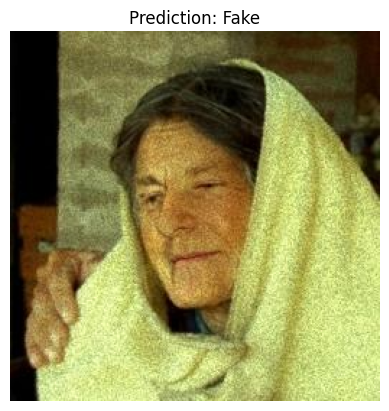

The image is classified as: Fake


In [17]:
import torch
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt

# Load the trained model
model = DeepfakeDetector().to(device)
model.load_state_dict(torch.load('deepfake_detector.pth'))
model.eval()

# Define image transformation (same as training)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Function to classify an image
def classify_image(image_path):
    image = Image.open(image_path).convert('RGB')  # Open the image
    img_tensor = transform(image).unsqueeze(0).to(device)  # Apply transformations & add batch dimension

    with torch.no_grad():
        output = model(img_tensor)  # Get model prediction
        _, predicted = torch.max(output, 1)  # Get the index of the highest probability

    label = "Fake" if predicted.item() == 1 else "Real"  # Class mapping

    # Display the image with prediction
    plt.imshow(image)
    plt.title(f"Prediction: {label}")
    plt.axis("off")
    plt.show()

    return label

# Example usage
image_path = "/kaggle/input/deepfake-and-real-images/Dataset/Test/Fake/fake_0.jpg"  # Provide the path to an image you want to test
result = classify_image(image_path)
print(f"The image is classified as: {result}")


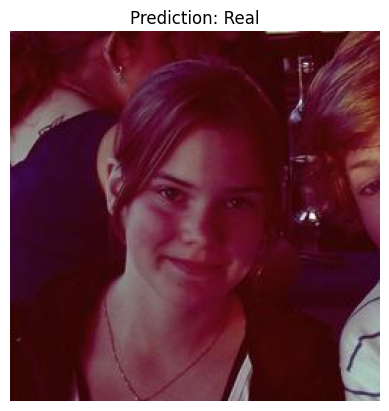

The image is classified as: Real


In [18]:
image_path = "/kaggle/input/deepfake-and-real-images/Dataset/Test/Real/real_0.jpg"  # Provide the path to an image you want to test
result = classify_image(image_path)
print(f"The image is classified as: {result}")